In [1]:
# 7-18-2026

In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr

In [3]:
embeddings = pd.read_csv("domain_embeddings_v4.csv")
vectors = pd.read_csv("../data/domain_koppen_vectors.csv")
koppen_cols = [c for c in vectors.columns if c.startswith("koppen_")]
embeddings.head()

,domain_id,e_0,e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8,src_bias,tgt_bias
0,0,0.044920,-0.140614,-0.092586,0.038657,0.091209,0.044721,-0.177195,0.017328,0.141784,0.204292,-0.017042
1,1,0.044615,-0.182949,-0.102645,0.036313,0.095344,0.107567,-0.248821,-0.000363,0.227570,0.176388,0.026637
2,2,0.065594,-0.110857,-0.039893,0.000854,0.076925,0.008618,-0.111971,-0.082349,0.096454,0.221703,-0.044998
3,4,0.081379,-0.068263,-0.103002,-0.023489,0.136152,0.028229,-0.148741,-0.059863,0.195213,0.231726,-0.063666
4,5,0.058112,-0.131804,-0.096756,0.065104,0.096903,0.066202,-0.164116,0.035039,0.129189,0.204279,-0.007497


In [4]:
full_merged = embeddings.merge(vectors, left_on="domain_id", right_on="domain", how="inner")
# only atmo brach dims (e_0, e_1, e_2)
atmo_cols = [c for c in embeddings.columns if c.startswith("e_")][0:3]
X_atmo = full_merged[atmo_cols].values

In [5]:
pca_atmo = PCA(n_components=2)
X_atmo_pca = pca_atmo.fit_transform(X_atmo)
print("explained variance ratio:", pca_atmo.explained_variance_ratio_)

explained variance ratio: [0.49752704 0.39210101]


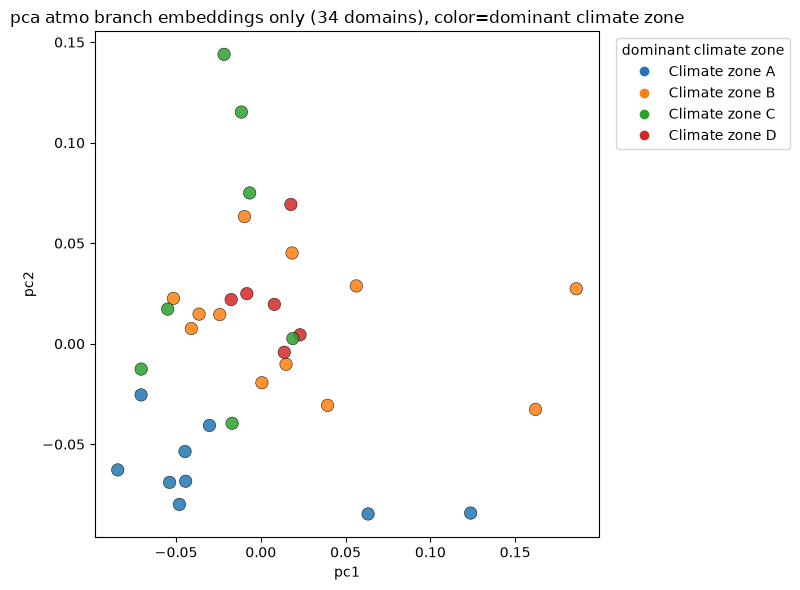

In [6]:
full_merged["dominant_koppen"] = full_merged[koppen_cols].idxmax(axis=1)
cat_codes = full_merged["dominant_koppen"].astype("category")
point_colors = [plt.cm.tab10.colors[i] for i in cat_codes.cat.codes]

plt.figure(figsize=(8, 6))
plt.scatter(
    X_atmo_pca[:, 0],
    X_atmo_pca[:, 1],
    c=point_colors,
    alpha=0.85,
    s=80,
    edgecolor="black",
    linewidth=0.4,
)
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=plt.cm.tab10.colors[i])
    for i in range(len(cat_codes.cat.categories))
]
# replce koppen w climate for easierr understanding of labels
clean_labels = [c.replace("koppen_", "Climate zone ").replace("_pct", "") for c in cat_codes.cat.categories]
plt.legend(handles, clean_labels, title="dominant climate zone", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xlabel("pc1")
plt.ylabel("pc2")
plt.title("pca atmo branch embeddings only (34 domains), color=dominant climate zone")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.neighbors import NearestNeighbors

k = 3
nn = NearestNeighbors(n_neighbors=k+1).fit(X_atmo_pca)
_, idx = nn.kneighbors(X_atmo_pca)

labels = cat_codes.cat.codes.values
agree = np.mean([
    np.mean(labels[idx[i, 1:]] == labels[i])
    for i in range(len(labels))
])
print(f"mean fraction of {k} nearest neighbors w same label: {agree:.4f}")

mean fraction of 3 nearest neighbors w same label: 0.4902


In [8]:
n_perms = 1000
rng = np.random.default_rng(0)
perm_scores = []

for _ in range(n_perms):
    shuffled = rng.permutation(labels)
    score = np.mean([
        np.mean(shuffled[idx[i, 1:]] == shuffled[i])
        for i in range(len(shuffled))
    ])
    perm_scores.append(score)

perm_scores = np.array(perm_scores)
print(f"baseline mean: {perm_scores.mean():.4f}, std: {perm_scores.std():.4f}")
print(f"z-scored frac nearest neighbor: {(agree - perm_scores.mean()) / perm_scores.std():.2f}")

baseline mean: 0.2455, std: 0.0520
z-scored frac nearest neighbor: 4.70


In [7]:
koppen_matrix = full_merged[koppen_cols].values

n = len(full_merged)
js_dist_grid = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        js_dist_grid[i, j] = jensenshannon(koppen_matrix[i], koppen_matrix[j])

# atmo embedding sq dist, all pairs
diff = X_atmo[:, None, :] - X_atmo[None, :, :]
atmo_sq_grid = (diff ** 2).sum(axis=-1)

In [8]:
off_diag_mask = ~np.eye(n, dtype=bool)
js_dist_od = js_dist_grid[off_diag_mask]
atmo_dist_od = atmo_sq_grid[off_diag_mask]

corr, p = spearmanr(atmo_dist_od, js_dist_od)
print(f"atmo branch sq dist vs koppen js divergence, off-diag spearman: {corr:.4f}")

atmo branch sq dist vs koppen js divergence, off-diag spearman: 0.2741


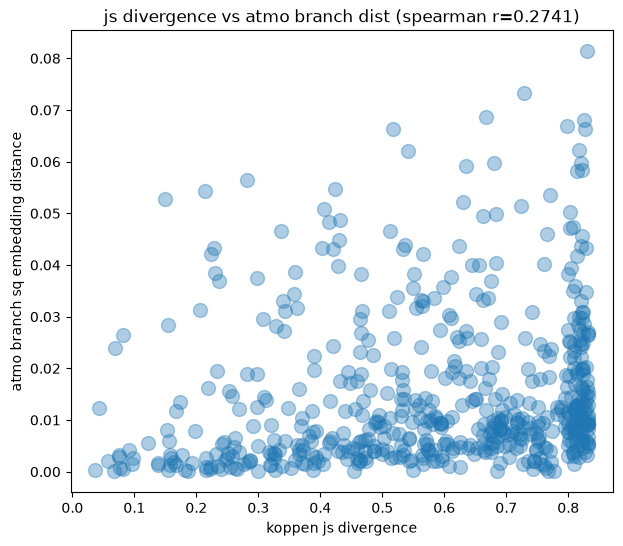

In [11]:
plt.figure(figsize=(7, 6))
plt.scatter(js_dist_od, atmo_dist_od, alpha=0.2, s=100)
plt.xlabel("koppen js divergence")
plt.ylabel("atmo branch sq embedding distance")
plt.title(f"js divergence vs atmo branch dist (spearman r={corr:.4f})")
plt.show()

In [ ]:
# seems like less corr than the fire branch dist vs pyrome js div, but once again the goal of the embeddings wasnt to recover composition. 
# the pca clearly shows clustering of different climate zones
# zones c and d overlap a lot, likely because they represent similar climates per the noaa classifications
#    with the main differentiator being avg low temp, which was not an input for the branch